# 並列対戦 → self/相手モデル学習ループ

指定したパスの重みを初期重みとして使います。ファイルがない場合は、そのパスへランダム初期重みを生成します。対戦中に作成済みの学習特徴量を高速バイナリ形式で保存し、3600エピソードごとにagent別のself/相手用へ再エンコードなしで振り分け、軽量CPU worker＋中央deviceの並列学習でself/相手モデルを継続学習します。

通常のエラー試合だけ不足した組み合わせを再試行します。100ターンまたは500選択へ達した試合は、その時点の残りサイドが少ない側を勝者、同数を引き分けとして学習episodeへ保存します。自分の手札は実データを使い、探索時に仮定した相手手札は教師データへ保存しません。

In [21]:
from __future__ import annotations

from datetime import datetime
import importlib
import os
import re
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import clear_output, display


def find_match_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'tools' / 'run_matches_round_robin.py').exists():
            return candidate
    raise FileNotFoundError('並列対戦リポジトリが見つかりません。')


MATCH_ROOT = find_match_root()
TRAIN_ROOT = MATCH_ROOT.parent / 'pokemon-tcg-agent-nomura'
RUNNER = MATCH_ROOT / 'tools' / 'run_matches_round_robin.py'
PREPROCESSOR = TRAIN_ROOT / 'tools' / 'train' / 'preprocess_match_agents.py'
TRAIN_SCRIPT = TRAIN_ROOT / 'tools' / 'train' / 'train_imitation.py'
PARALLEL_TRAINER = MATCH_ROOT / 'tools' / 'benchmark_parallel_training.py'
venv_python = MATCH_ROOT / '.venv' / ('Scripts/python.exe' if os.name == 'nt' else 'bin/python')
PYTHON = venv_python if venv_python.exists() else Path(sys.executable)
for required in (PREPROCESSOR, TRAIN_SCRIPT, PARALLEL_TRAINER):
    if not required.exists():
        raise FileNotFoundError(f'並列学習に必要なスクリプトがありません: {required}')
if str(MATCH_ROOT) not in sys.path:
    sys.path.insert(0, str(MATCH_ROOT))

import tools.parallel_selfplay_training as selfplay_training
importlib.reload(selfplay_training)
run_parallel_games = selfplay_training.run_parallel_games
train_models = selfplay_training.train_models
read_parallel_training_metrics = selfplay_training.read_parallel_training_metrics
MODEL_SOURCE_ROOT = MATCH_ROOT / 'agents' / 'rl_mcts' / 'src'
if str(MODEL_SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(MODEL_SOURCE_ROOT))
from rl_mcts.model import create_model

print(f'MATCH_ROOT={MATCH_ROOT}')
print(f'TRAIN_ROOT={TRAIN_ROOT}')
print(f'PYTHON={PYTHON}')

MATCH_ROOT=/Users/naoki/Desktop/develop/pokemon_tgc_agent/pokemon-tcg-agent
TRAIN_ROOT=/Users/naoki/Desktop/develop/pokemon_tgc_agent/pokemon-tcg-agent-nomura
PYTHON=/Users/naoki/Desktop/develop/pokemon_tgc_agent/pokemon-tcg-agent/.venv/bin/python


## 設定

指定したパスをモデルの保存先兼読み込み元にします。各重みファイルがあればそのまま初期重みに使い、なければランダム初期重みを生成します。論理CPUを1つ中央処理用に残し、残りをゲームworkerと学習workerにします。1回のモデル更新までに回す試合数は `GAME_WORKERS × LANES_PER_WORKER`、学習内部のミニバッチサイズは `TRAIN_MINIBATCH_SIZE` です。学習中は全self/相手モデルの平均loss・value loss・policy loss・accuracyをリアルタイム更新します。CPU/GPU/RAM使用率などの計測処理はありません。

In [22]:
TRAINING_AGENTS_ROOT = (
    MATCH_ROOT / 'agents' / '16model_pretrained'
)
AGENTS = {
    f'cluster_{index:02d}': (
        TRAINING_AGENTS_ROOT / f'cluster_{index:02d}' / 'src' / 'main.py'
    )
    for index in range(16)
}

SEED = 0


def ensure_model_file(model_path: Path, seed: int) -> str:
    if model_path.is_file():
        return 'existing'
    if model_path.exists():
        raise FileExistsError(f'モデル保存先がファイルではありません: {model_path}')
    torch.manual_seed(seed)
    temporary = model_path.with_name(
        f'.{model_path.name}.{os.getpid()}.tmp'
    )
    try:
        torch.save(create_model().state_dict(), temporary)
        os.replace(temporary, model_path)
    finally:
        temporary.unlink(missing_ok=True)
    return 'random-created'


INITIAL_WEIGHT_STATUS = {}
for agent_name, main_path in AGENTS.items():
    for required in (main_path, main_path.parent / 'deck.csv'):
        if not required.is_file():
            raise FileNotFoundError(f'{agent_name}のagentファイルがありません: {required}')
    agent_index = int(agent_name.rsplit('_', 1)[1])
    INITIAL_WEIGHT_STATUS[agent_name] = {
        'self': ensure_model_file(
            main_path.parent / 'model.pth', SEED + agent_index * 2
        ),
        'opponent': ensure_model_file(
            main_path.parent / 'opponent_model.pth',
            SEED + agent_index * 2 + 1,
        ),
    }

CPU_THREADS = os.cpu_count() or 1
GAME_WORKERS = max(1, CPU_THREADS - 1)
TRAINING_WORKERS = max(1, CPU_THREADS - 1)
LANES_PER_WORKER = 400

MATCH_BATCH_SIZE = 256
SEARCH_COUNT = 10
MAX_TURNS = 100
MAX_SELECTIONS = 500
MAX_MATCH_ATTEMPTS = 5
MATCH_DEVICE = 'mps' if sys.platform == 'darwin' else 'cuda'

TRAINING_UPDATES = 200
TRAIN_EPOCHS = 1
TRAIN_MINIBATCH_SIZE = 128
LEARNING_RATE = 3e-4
SHARD_SIZE = 20_000
TRAIN_DEVICE = 'auto'
TRAIN_DEVICE_WAVE_SIZE = TRAINING_WORKERS
LOSS_POLL_INTERVAL_SECONDS = 0.5
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S_%f')
RUN_ROOT = MATCH_ROOT / 'results' / 'training_loop' / RUN_ID

EPISODES_PER_UPDATE = GAME_WORKERS * LANES_PER_WORKER
MODEL_EPISODE_PATTERN = re.compile(r'model_episode(\d+)')
START_EPISODES = max(
    (
        int(match.group(1))
        for path in TRAINING_AGENTS_ROOT.iterdir()
        if path.is_dir() and (match := MODEL_EPISODE_PATTERN.fullmatch(path.name))
    ),
    default=0,
)
TOTAL_EPISODES = START_EPISODES + EPISODES_PER_UPDATE * TRAINING_UPDATES
print(
    f'start_episodes={START_EPISODES}, final_episodes={TOTAL_EPISODES}, '
    f'new_episodes={TOTAL_EPISODES - START_EPISODES}, updates={TRAINING_UPDATES}, '
    f'train_epochs/update={TRAIN_EPOCHS}, agents={len(AGENTS)}, '
    f'game_workers={GAME_WORKERS}, lanes/worker={LANES_PER_WORKER}, '
    f'episodes/update={EPISODES_PER_UPDATE}, '
    f'training_workers={TRAINING_WORKERS}, wave={TRAIN_DEVICE_WAVE_SIZE}, '
    f'train_minibatch={TRAIN_MINIBATCH_SIZE}, '
    f'training_agents={TRAINING_AGENTS_ROOT}, output={RUN_ROOT}'
)

start_episodes=10800, final_episodes=730800, new_episodes=720000, updates=200, train_epochs/update=1, agents=16, game_workers=9, lanes/worker=400, episodes/update=3600, training_workers=9, wave=9, train_minibatch=128, training_agents=/Users/naoki/Desktop/develop/pokemon_tgc_agent/pokemon-tcg-agent/agents/16model_pretrained, output=/Users/naoki/Desktop/develop/pokemon_tgc_agent/pokemon-tcg-agent/results/training_loop/20260802_052355_765867


In [23]:
LOSS_HISTORY: dict[tuple[int, str, int], dict] = {}
LOSS_HISTORY_PATH = RUN_ROOT / 'loss_history.csv'


def remember_loss_metrics(metrics: list[dict], completed_episodes: int) -> None:
    global_update = completed_episodes // EPISODES_PER_UPDATE
    for metric in metrics:
        row = dict(metric)
        row['update'] = global_update
        row['completed_episodes'] = completed_episodes
        row['global_epoch'] = (global_update - 1) * TRAIN_EPOCHS + int(row['epoch']) + 1
        key = (completed_episodes, str(row['job']), int(row['epoch']))
        LOSS_HISTORY[key] = row


def load_previous_loss_history(max_episodes: int) -> None:
    latest_episode_dirs: dict[int, Path] = {}
    history_root = MATCH_ROOT / 'results' / 'training_loop'
    if not history_root.is_dir():
        return
    for episode_dir in history_root.glob('*/episode*'):
        match = re.fullmatch(r'episode(\d+)', episode_dir.name)
        if not match:
            continue
        completed_episodes = int(match.group(1))
        metrics_root = episode_dir / 'learning' / 'parallel_training'
        if completed_episodes > max_episodes or not any(metrics_root.glob('jobs/*/metrics.csv')):
            continue
        previous = latest_episode_dirs.get(completed_episodes)
        if previous is None or episode_dir.parent.name > previous.parent.name:
            latest_episode_dirs[completed_episodes] = episode_dir
    for completed_episodes, episode_dir in sorted(latest_episode_dirs.items()):
        metrics_root = episode_dir / 'learning' / 'parallel_training'
        remember_loss_metrics(
            read_parallel_training_metrics(metrics_root), completed_episodes
        )


def save_loss_history() -> pd.DataFrame:
    frame = (
        pd.DataFrame(LOSS_HISTORY.values())
        .sort_values(['completed_episodes', 'epoch', 'job'])
        .reset_index(drop=True)
    )
    LOSS_HISTORY_PATH.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(LOSS_HISTORY_PATH, index=False)
    return frame


def draw_live_loss(metrics: list[dict], completed_episodes: int) -> None:
    remember_loss_metrics(metrics, completed_episodes)
    clear_output(wait=True)
    if not LOSS_HISTORY:
        print(
            '学習プロセスを実行中です。最初のlossは、'
            'いずれかのモデルが1 epochを完了すると表示されます。'
        )
        return

    frame = save_loss_history()
    averages = (
        frame.groupby(['global_epoch', 'completed_episodes'], as_index=False)[
            ['loss', 'loss_value', 'loss_policy', 'train_accuracy']
        ].mean()
    )
    current = frame[frame['completed_episodes'] == completed_episodes]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    steps = averages['completed_episodes']
    axes[0].plot(steps, averages['loss'], marker='o', label='total')
    axes[0].plot(steps, averages['loss_value'], marker='o', label='value')
    axes[0].plot(steps, averages['loss_policy'], marker='o', label='policy')
    axes[0].set(title='Mean loss across all updates', xlabel='completed games', ylabel='loss')
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(steps, averages['train_accuracy'], marker='o', color='tab:green')
    axes[1].set(title='Mean training accuracy across all updates', xlabel='completed games', ylabel='accuracy', ylim=(0, 1))
    axes[1].grid(alpha=0.3)
    expected_current = len(AGENTS) * 2 * TRAIN_EPOCHS
    latest_mean_loss = current.loss.mean() if not current.empty else averages.loss.iloc[-1]
    fig.suptitle(
        f'Games {completed_episodes}/{TOTAL_EPISODES}, '
        f'training update {(completed_episodes - START_EPISODES) // EPISODES_PER_UPDATE}'
        f'/{TRAINING_UPDATES}: '
        f'{len(current)}/{expected_current} job-epochs reported, '
        f'cumulative={len(frame)}, latest mean loss={latest_mean_loss:.4f}'
    )
    fig.tight_layout()
    display(fig)
    plt.close(fig)


load_previous_loss_history(START_EPISODES)


def run_episode_batch(completed_episodes: int, update_index: int) -> dict:
    episode_root = RUN_ROOT / f'episode{completed_episodes}'
    episodes_dir = episode_root / 'episodes'
    learning_dir = episode_root / 'learning'
    checkpoint_dir = TRAINING_AGENTS_ROOT / f'model_episode{completed_episodes}'

    episode_count = run_parallel_games(
        python=PYTHON,
        runner=RUNNER,
        match_root=MATCH_ROOT,
        agents=AGENTS,
        episodes_dir=episodes_dir,
        workers=GAME_WORKERS,
        lanes_per_worker=LANES_PER_WORKER,
        include_self=True,
        match_batch_size=MATCH_BATCH_SIZE,
        search_count=SEARCH_COUNT,
        device=MATCH_DEVICE,
        seed=SEED + update_index,
        max_turns=MAX_TURNS,
        max_selections=MAX_SELECTIONS,
        max_attempts=MAX_MATCH_ATTEMPTS,
    )

    def record_training_progress(metrics: list[dict]) -> None:
        draw_live_loss(metrics, completed_episodes)

    training_summary = train_models(
        python=PYTHON,
        preprocessor=PREPROCESSOR,
        train_script=TRAIN_SCRIPT,
        parallel_trainer=PARALLEL_TRAINER,
        train_root=TRAIN_ROOT,
        match_root=MATCH_ROOT,
        agents=AGENTS,
        episodes_dir=episodes_dir,
        work_dir=learning_dir,
        checkpoint_dir=checkpoint_dir,
        epochs=TRAIN_EPOCHS,
        train_minibatch_size=TRAIN_MINIBATCH_SIZE,
        learning_rate=LEARNING_RATE,
        shard_size=SHARD_SIZE,
        device=TRAIN_DEVICE,
        seed=SEED + update_index * 100,
        training_workers=TRAINING_WORKERS,
        device_wave_size=TRAIN_DEVICE_WAVE_SIZE,
        progress_callback=record_training_progress,
        poll_interval_seconds=LOSS_POLL_INTERVAL_SECONDS,
    )
    return {
        'completed_episodes': completed_episodes,
        'batch_episodes': episode_count,
        'output': str(episode_root),
        'checkpoint': str(checkpoint_dir),
        'training_seconds': training_summary['trainingSeconds'],
        'training_mode': training_summary['executionMode'],
        'initial_weights': str(TRAINING_AGENTS_ROOT),
    }


def run_training_loop(total_episodes: int = TOTAL_EPISODES) -> pd.DataFrame:
    new_episode_count = total_episodes - START_EPISODES
    if new_episode_count < 0 or new_episode_count % EPISODES_PER_UPDATE != 0:
        raise ValueError(
            f'total_episodes - start_episodes={new_episode_count}は'
            f'episodes_per_update={EPISODES_PER_UPDATE}の倍数にしてください。'
        )
    RUN_ROOT.mkdir(parents=True, exist_ok=False)
    if LOSS_HISTORY:
        draw_live_loss([], START_EPISODES)
    rows = []
    for update_index, completed_episodes in enumerate(
        range(
            START_EPISODES + EPISODES_PER_UPDATE,
            total_episodes + 1,
            EPISODES_PER_UPDATE,
        )
    ):
        rows.append(run_episode_batch(completed_episodes, update_index))
        display(pd.DataFrame(rows))
    return pd.DataFrame(rows)

## ループ実行

このセルを実行すると、指定したフォルダにある最新の `model_episode...` の番号から試合数を継続し、3600エピソードのworker-batched対戦→前処理→中央device並列学習を繰り返します。保存するモデルのフォルダ名も累積試合数に合わせます。過去分を含むloss履歴をCSVへ保存し、全期間の平均lossグラフを更新します。

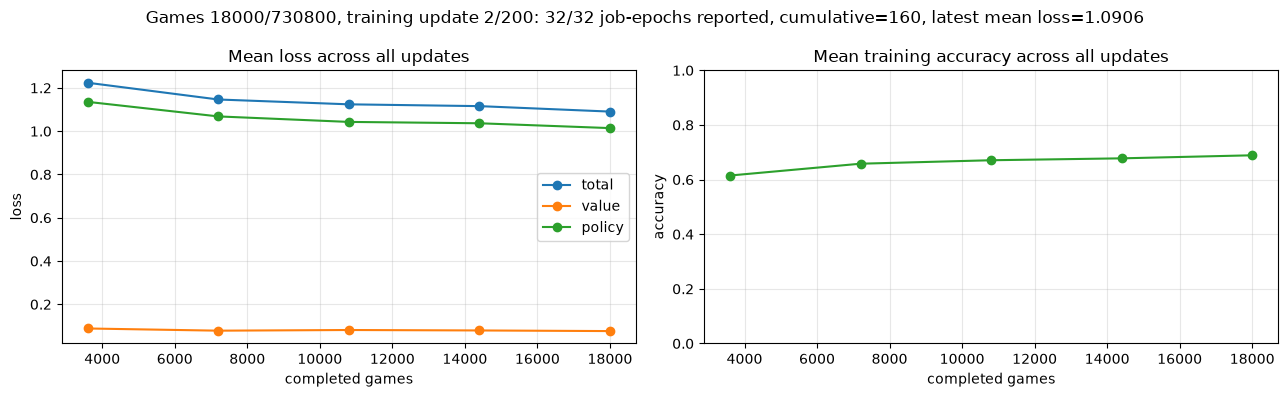

episode checkpoint training done: preprocess=10.3s training=170.3s total=181.7s


,completed_episodes,batch_episodes,output,checkpoint,training_seconds,training_mode,initial_weights
0,14400,3600,/Users/naoki/Desktop/develop/pokemon_tgc_agent...,/Users/naoki/Desktop/develop/pokemon_tgc_agent...,212.231888,central-device,/Users/naoki/Desktop/develop/pokemon_tgc_agent...
1,18000,3600,/Users/naoki/Desktop/develop/pokemon_tgc_agent...,/Users/naoki/Desktop/develop/pokemon_tgc_agent...,170.324437,central-device,/Users/naoki/Desktop/develop/pokemon_tgc_agent...


parallel games: workers=9, lanes/worker=400, games=3600, pairings=136, self=yes, limits=100 turns/500 selections
balanced schedule: matches/agent=424〜424, player-sides/agent=450〜450


In [ ]:
results = run_training_loop()
print(f'completed: {RUN_ROOT}')